# Part 2.5
In order to understand our dataset more deeply we will take some time illustrating the data.

First we find out how many of the ID's are actually present in the last 3 years, then we plot the main contributers for those years.

In [ ]:
#Imports
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

#Our dataframe
final_df = pd.read_csv("cleaned_data/cleaned_df_final_test.csv") #TEMP NAME, remember to change.
#Variables that we need

In [ ]:
#3 years from end of dataset
three_years = pd.Timedelta(days=365*3 + 1)
print(final_df["date"].max())
last_date = final_df["date"].max()
last_date = pd.to_datetime(last_date)
three_years_ago = last_date - three_years
print(three_years_ago)
print("--------------")
final_df["date"] = pd.to_datetime(final_df["date"])

last_three_years_df = final_df[final_df["date"] >= three_years_ago]
print(last_three_years_df["date"].min())
print(last_three_years_df["date"].max())

rm_ids = []
cumsums_per_id = []

for id, group in last_three_years_df.groupby("rm_id", sort=False):
    cumsum_by_start = group["cumulative_weight"].min()
    cumsum_by_end = group["cumulative_weight"].max()
    cumsum_diff = (cumsum_by_end-cumsum_by_start).astype(int).item()
    rm_ids.append(id)
    cumsums_per_id.append(cumsum_diff)

important_ids = pd.DataFrame({"rm_id" : rm_ids})
important_ids["cumsums"] = cumsums_per_id
total_cumsum_3_years = important_ids["cumsums"].sum()
important_ids["proportion"] = important_ids["cumsums"] / total_cumsum_3_years
important_ids = important_ids.sort_values(by="cumsums", ascending=False)
print(important_ids.tail(n=5))


2024-12-19 11:34:00+00:00
2021-12-19 11:34:00+00:00
--------------
2021-12-19 11:34:00+00:00
2024-12-19 11:34:00+00:00
     rm_id   cumsums  proportion
177   3865  17997845    0.069043
71    2140  19768971    0.075838
148   3126  22855930    0.087680
172   3781  26317536    0.100959
76    2130  52368756    0.200897


## Plotting for most common.

In [ ]:

def plot_id_3years(id):
    df = last_three_years_df[last_three_years_df["rm_id"] == id]
    x = df["date"]
    y = df["cumulative_weight"]

    sns.set_theme()
    plt.plot(x,y)

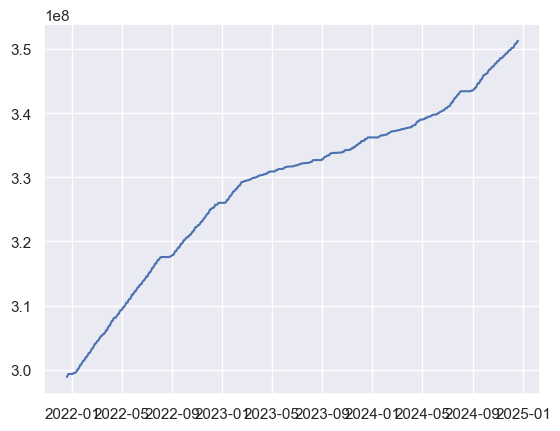

In [9]:
plot_id_3years(2130)

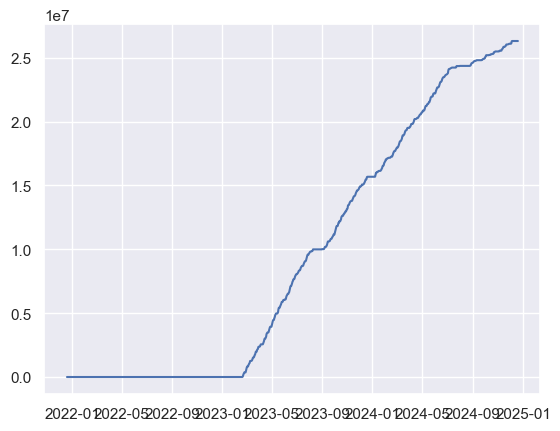

In [10]:
plot_id_3years(3781)

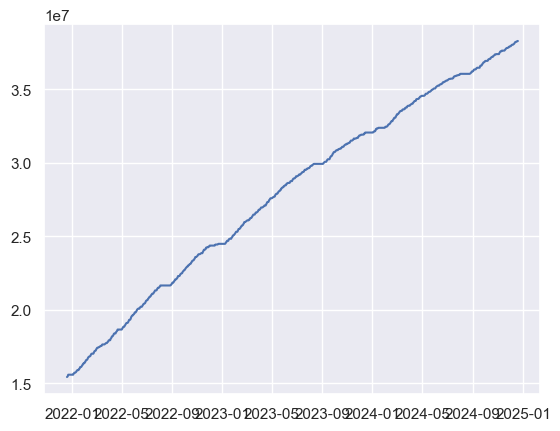

In [12]:
plot_id_3years(3126)


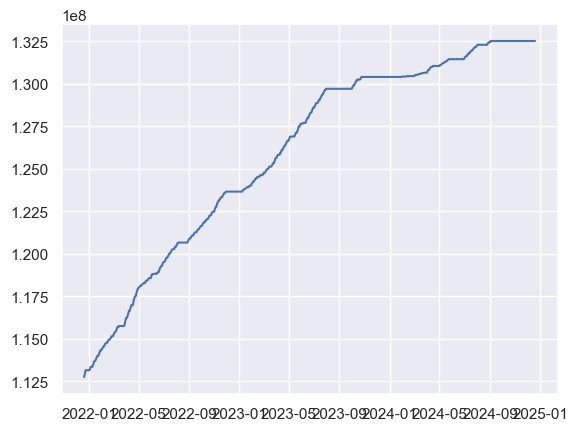

In [13]:
plot_id_3years(2140)


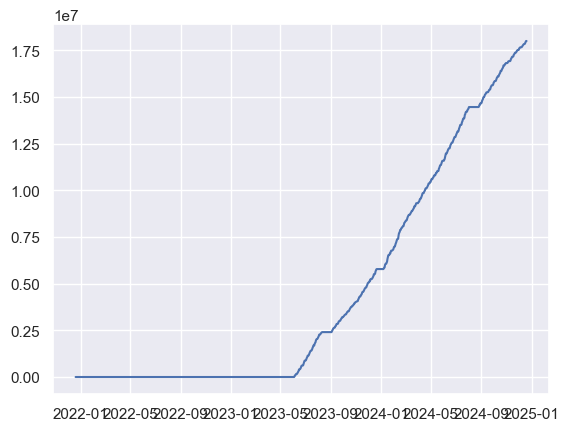

In [14]:
plot_id_3years(3865)